# Reconstruct Stokes profile from ERA5 wave output
- Author: Muxin Hu
- created time: 12.04.2026
- modified time: 13.04.2026

In [1]:
import xarray as xr
import numpy as np
import pyicon as pyic
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
import cmocean as cmo
import cartopy.crs as ccrs
import cartopy.feature as cfeature
%matplotlib inline
from distributed import Client, LocalCluster
import dask

----Start loading pyicon.
Loading default parameters from /home/m/m301254/Download/pyicon/pyicon/params_default.json.


ERROR 1: PROJ: proj_create_from_database: Open of /home/m/m301254/.conda/envs/env02_waves/share/proj failed


----Start loading pyicon.
----Pyicon was loaded successfully.
----Pyicon was loaded successfully.


In [2]:
cluster = LocalCluster(
    n_workers=32, 
    threads_per_worker=2,
    local_directory="/scratch/m/m301254/dask_tmp/"
)
client = Client(cluster)
client.restart()   
client

/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/contextlib.py:144: UserWarning: Creating scratch directories is taking a surprisingly long time. (1.24s) This is often due to running workers on a network file system. Consider specifying a local-directory to point workers to write scratch data to a local disk.
  next(self.gen)
2026-05-06 16:39:05,111 - distributed.nanny - WARNING - Restarting worker
2026-05-06 16:39:05,120 - distributed.nanny - WARNING - Restarting worker
2026-05-06 16:39:05,154 - distributed.nanny - WARNING - Restarting worker
2026-05-06 16:39:05,163 - distributed.nanny - WARNING - Restarting worker
2026-05-06 16:39:05,165 - distributed.nanny - WARNING - Restarting worker
2026-05-06 16:39:05,183 - distributed.nanny - WARNING - Restarting worker
2026-05-06 16:39:05,185 - distributed.nanny - WARNING - Restarting worker
2026-05-06 16:39:05,191 - distributed.nanny - WARNING - Restarting worker
2026-05-06 16:39:05,195 - distributed.nanny - WARNING - Restarting worker


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 32
Total threads: 64,Total memory: 251.62 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34895,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:41647,Total threads: 2
Dashboard: http://127.0.0.1:33929/status,Memory: 7.86 GiB
Nanny: tcp://127.0.0.1:46069,


## Read Data

In [3]:
# read data
wave_globe = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/era5_Stokes_mean_wave_parameters.grib",engine="cfgrib")
stokes_globe = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/era5_Stokes_surface_uv_2024.grib",engine="cfgrib")

In [16]:
wave_globe

<xarray.Dataset> Size: 82GB
Dimensions:     (time: 8784, latitude: 361, longitude: 720)
Coordinates:
  * time        (time) datetime64[ns] 70kB 2024-01-01 ... 2024-12-31T23:00:00
  * latitude    (latitude) float64 3kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude   (longitude) float64 6kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
    number      int64 8B ...
    step        timedelta64[ns] 8B ...
    meanSea     float64 8B ...
    valid_time  (time) datetime64[ns] 70kB dask.array<chunksize=(8784,), meta=np.ndarray>
Data variables:
    mwd         (time, latitude, longitude) float32 9GB dask.array<chunksize=(2164, 88, 176), meta=np.ndarray>
    swh         (time, latitude, longitude) float32 9GB dask.array<chunksize=(2164, 88, 176), meta=np.ndarray>
    mdts        (time, latitude, longitude) float32 9GB dask.array<chunksize=(2164, 88, 176), meta=np.ndarray>
    mdww        (time, latitude, longitude) float32 9GB dask.array<chunksize=(2164, 88, 176), meta=np.ndarray>
    mp1         (time, latitude, longitude) float32 9GB dask.array<chunksize=(2164, 88, 176), meta=np.ndarray>
    p1ps        (time, latitude, longitude) float32 9GB dask.array<chunksize=(2164, 88, 176), meta=np.ndarray>
    p1ww        (time, latitude, longitude) float32 9GB dask.array<chunksize=(2164, 88, 176), meta=np.ndarray>
    shts        (time, latitude, longitude) float32 9GB dask.array<chunksize=(2164, 88, 176), meta=np.ndarray>
    shww        (time, latitude, longitude) float32 9GB dask.array<chunksize=(2164, 88, 176), meta=np.ndarray>
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-05T11:14 GRIB to CDM+CF via cfgrib-0.9.1...

In [17]:
stokes_globe

<xarray.Dataset> Size: 18GB
Dimensions:     (time: 8784, latitude: 361, longitude: 720)
Coordinates:
  * time        (time) datetime64[ns] 70kB 2024-01-01 ... 2024-12-31T23:00:00
  * latitude    (latitude) float64 3kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude   (longitude) float64 6kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
    number      int64 8B ...
    step        timedelta64[ns] 8B ...
    meanSea     float64 8B ...
    valid_time  (time) datetime64[ns] 70kB dask.array<chunksize=(8784,), meta=np.ndarray>
Data variables:
    ust         (time, latitude, longitude) float32 9GB dask.array<chunksize=(2164, 88, 176), meta=np.ndarray>
    vst         (time, latitude, longitude) float32 9GB dask.array<chunksize=(2164, 88, 176), meta=np.ndarray>
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-05T11:14 GRIB to CDM+CF via cfgrib-0.9.1...

## Estimate: Stokes transport
- Formula: $$\mathbf{V_s}\approx \frac{\pi H_s^2}{8 \overline{T}} \hat{\mathbf {k}}_s$$
    - using: mean wave significant height $H_s$, direction $\hat{\mathbf {k}}_s$, and period $\overline{T}$, either from:
        - **Separated in wind wave and total swells**
            - Treating each kind as monochromatic wave with narrow spectrum band
            - Two wave systems exist, can account for opposing Stokes transports from two groups. More consistent
        - **Combined wind waves and swell**
            - single-direction approximation
    - the mean wave period should be the **mean wave period based on first moment of waves** by definition
    - mean wave direction is a better directional proxy for transport than surface Stokes drift (Breivik et al., 2014)
        - "**Breivil et al. (2014) suggests that it is better to estimate the transport direction from the mean wave direction raher than from the surface Stokes advection**, as the Stokes transport is more influenced by the low-frequency wave (i.e., swells) in principle. The mean wave direction represents bulk spectrum, and is much closer to transport direction. Evidence shows mean wave direction differing from transport direction only by ~2 degree on average"

In [4]:
print(wave_globe["shww"].chunks)
print(wave_globe["shts"].chunks)

((720, 720, 720, 720, 720, 720, 720, 720, 720, 720, 720, 720, 144), (180, 180, 1), (360, 360))
((720, 720, 720, 720, 720, 720, 720, 720, 720, 720, 720, 720, 144), (180, 180, 1), (360, 360))


In [7]:
# Estimate the Stokes transport (unit: m^2/s)
def estimate_stokes_transport(Hs, T, theta_from_deg):
    """
    theta_drom_deg: the raw ERA5 data are degrees that waves are coming FROM, 
    so zero means 'coming from the north' and 90 'coming from the east'.
    """
    # convert coming from to propagating toward
    theta = np.deg2rad((theta_from_deg + 180) % 360)

    Vs_mag = np.pi * Hs**2 / (8 * T)
    Vs_u = Vs_mag * np.sin(theta) # eastward
    Vs_v = Vs_mag * np.cos(theta) # northward
    
    return Vs_u, Vs_v

## No separation between wind wave and total swells
- Use the direct estimation of Stokes transport $\mathbf V_{s}$ from the mean wave direction/period/height
- Stokes profile direction follows the surface Stokes velocity direction
- Two approximated profiles:
    - Exponential Integral Profile (Breivik et al. 2014)
    - Phillips Spectrum Profile (Breivik et al. 2016)

### Stokes transport from mean wave parameters

In [6]:
# directly estimated from mean wave direction/period/height
Vst_u_direct, Vst_v_direct = estimate_stokes_transport(wave_globe["swh"], wave_globe["mp1"], wave_globe["mwd"])
ds_Vst_direct = xr.Dataset({
    "Vst_u_direct":  Vst_u_direct,
    "Vst_v_direct":  Vst_v_direct
}).compute()

/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 10.35 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [ ]:
ds_Vst_direct.to_netcdf("/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/era5_Stokes_transport_estimated_direct_2024.nc")

### Exponential Integral Profile (Breivik et al. 2014)
- Following the parameterization of **Breivik et al. (2014)** to approximate the Stokes drift profile into an exponential integral profile base on two estimated parameters: 
    - the Stokes transport ($\mathbf V_s$) 
    - the surface Stokes drift velocity ($\mathbf u_s(0)$). 
- **The Stokes drift velocity as a function of depth $z$ (positive downward)** is given by: $$\mathbf {u}_s(z)=\mathbf {u}_s(0)\frac{e^{-2k_ez}}{1+Ck_ez} \tag{1}$$
    - where: $$C\approx 8 \tag{2}$$
    - and the **inverse depth scale $k_e$** is defined as $$ k_e =\frac{|\mathbf {u}_s(0)|[e^{1/4}E_1(1/4)]}{8|\mathbf V_s|},\quad \text{with}\quad e^{1/4}E_1(1/4)\approx 1.34. \tag{3}$$
        - According to Janssen et al., (2013) "Air-Sea Interaction and Surface Waves", the inverse depth scale is calculated using the magnitudes of both the surface Stokes drift velocity and the estimated Stokes transport.

In [30]:
ds_Vst_direct = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/era5_Stokes_transport_estimated_direct_2024.nc")

#### 2024 January

In [31]:
# surface Stokes
chunks = {"time": 48, "latitude": 88, "longitude": 176}

ust0 = stokes_globe["ust"].sel(time=slice("2024-01-01", "2024-02-01")).chunk(chunks)
vst0 = stokes_globe["vst"].sel(time=slice("2024-01-01", "2024-02-01")).chunk(chunks)
ust0_mag = xr.apply_ufunc(
    np.hypot, ust0, vst0,
    dask="parallelized",
    output_dtypes=[float]
)

Vst_u_direct = ds_Vst_direct["Vst_u_direct"].sel(time=slice("2024-01-01", "2024-02-01")).chunk(chunks)
Vst_v_direct = ds_Vst_direct["Vst_v_direct"].sel(time=slice("2024-01-01", "2024-02-01")).chunk(chunks)
Vst_mag = xr.apply_ufunc(
    np.hypot,
    Vst_u_direct,
    Vst_v_direct,
    dask="parallelized",
    output_dtypes=[float]
)

In [32]:
print(type(ust0_mag.data))
print(type(Vst_mag.data))

<class 'dask.array.core.Array'>
<class 'dask.array.core.Array'>


In [33]:
# inverse depth scale
k_e = (1.34 * ust0_mag) / (8 * xr.where(Vst_mag > 0, Vst_mag, np.nan))
k_e = k_e.chunk(ust0.chunksizes).persist()

In [34]:
# define the depth space
z = xr.DataArray(
    np.array([0, 1, 2, 3, 4, 5, 7, 9, 11, 13, 15, 20, 25, 30, 40, 50]),
    dims="depth",
    coords={"depth": np.array([0, 1, 2, 3, 4, 5, 7, 9, 11, 13, 15, 20, 25, 30, 40, 50])},
    name="depth",
    attrs={
        "long_name": "depth below sea surface",
        "units": "m",
        "positive": "down"
    }
)

# broadcast to 4D
k_e_4d, z_4d = xr.broadcast(k_e, z)
ust0_4d, _ = xr.broadcast(ust0, z)
vst0_4d, _ = xr.broadcast(vst0, z)

In [ ]:
# profile shape
f_z = np.exp(-2 * k_e_4d * z_4d) / (1 + 8 * k_e_4d * z_4d)

# two directions
ust_z = ust0_4d * f_z
vst_z = vst0_4d * f_z

In [ ]:
ds_profile = xr.Dataset({
    "ust_z": ust_z,
    "vst_z": vst_z,
    "k_e": k_e
})
ds_profile = ds_profile.astype("float32")

# final chunks for consistency and efficient compression
final_chunks = {
    "time": 48,
    "latitude": 88,
    "longitude": 176,
    "depth": -1
}

ds_profile = ds_profile.chunk(final_chunks)

# compression settings
encoding = {
    "ust_z": {"zlib": True, "complevel": 4, "shuffle": True, "chunksizes": (48, 88, 176, 16)},
    "vst_z": {"zlib": True, "complevel": 4, "shuffle": True, "chunksizes": (48, 88, 176, 16)},
    "k_e":   {"zlib": True, "complevel": 4, "shuffle": True, "chunksizes": (48, 88, 176)}
}

# output
outdir = "/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/"
ds_profile.to_netcdf(
    f"{outdir}era5_Stokes_profile_exponential_2024_Jan.nc",
    encoding=encoding
)

In [4]:
outdir = "/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/"
stokes_uv = xr.open_dataset(f"{outdir}era5_Stokes_profile_exponential_2024_Jan.nc")
stokes_uv_so = stokes_uv.isel(latitude=slice(-60, -50), longitude=slice(260, 270))

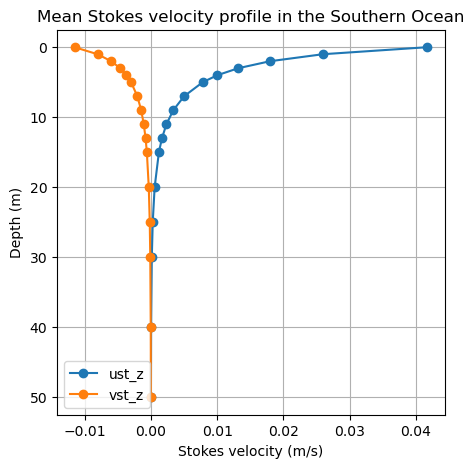

In [52]:
# calculate the mean profile in the Southern Ocean region
stokes_uv_so_mean = stokes_uv_so.mean(dim={"time", "latitude", "longitude"})

# plot the mean profile
plt.figure(figsize=(5, 5))
plt.plot(stokes_uv_so_mean["ust_z"], stokes_uv_so_mean["depth"], label="ust_z", marker="o")
plt.plot(stokes_uv_so_mean["vst_z"], stokes_uv_so_mean["depth"], label="vst_z", marker="o")
plt.gca().invert_yaxis()
plt.xlabel("Stokes velocity (m/s)")
plt.ylabel("Depth (m)")
plt.title("Mean Stokes velocity profile in the Southern Ocean")
plt.legend()
plt.grid()
plt.show()

### Phillips Spectrum Profile (Breivik et al. 2016)
- Following the **Breivik et al. 2016** to approximate Stokes drift profile as:  $$\begin{equation} \mathbf{v}_s(z)\approx v_0 \biggl\{e^{-2\overline{k}|z|} -\beta\sqrt{2\pi \overline{k}|z|}\biggr[\mathbf{erfc}(\sqrt{2\overline{k}|z|})\biggr]\biggl\} \end{equation}$$
- where:
    - $\beta$: a parameter, which is exactly one in Phillips spectrum
        - (Breivik et al., 2016)found $\beta=1$ yield good agreement between modeled and parameterised Stokes drift profiles.
    - $\overline k$: **inverse depth scale**, which can be determined given an estimate of the transport $\mathbf{V}_s$ and the surface Stokes drift velocity $v_0$ by: $$\overline k=\frac{v_0}{2\mathbf{V}_s}(1-2\beta/3) $$
- Estimation of Stokes transport according to Eq. (26) (equivalent to Eq. (38)) using bulk-wave parameters
- Surface stokes drift velocity can to be separated into wind wave and total swells (or swell partition 1/2/3) components

#### 2024 January

In [4]:
import scipy.special as sps
ds_Vst_direct = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/era5_Stokes_transport_estimated_direct_2024.nc")

In [5]:
# surface Stokes
chunks = {"time": 48, "latitude": 88, "longitude": 176}

ust0 = stokes_globe["ust"].sel(time=slice("2024-01-01", "2024-02-01")).chunk(chunks)
vst0 = stokes_globe["vst"].sel(time=slice("2024-01-01", "2024-02-01")).chunk(chunks)
ust0_mag = xr.apply_ufunc(
    np.hypot, ust0, vst0,
    dask="parallelized",
    output_dtypes=[float]
)

Vst_u_direct = ds_Vst_direct["Vst_u_direct"].sel(time=slice("2024-01-01", "2024-02-01")).chunk(chunks)
Vst_v_direct = ds_Vst_direct["Vst_v_direct"].sel(time=slice("2024-01-01", "2024-02-01")).chunk(chunks)
Vst_mag = xr.apply_ufunc(
    np.hypot,
    Vst_u_direct,
    Vst_v_direct,
    dask="parallelized",
    output_dtypes=[float]
)

In [6]:
beta = 1.0
eps = 1e-12

Vst_safe = xr.where(Vst_mag > eps, Vst_mag, np.nan)

# k_bar
k_bar = (ust0_mag / (2 * Vst_safe)) * (1 - 2 * beta / 3)

k_bar = k_bar.chunk(chunks).persist()

In [7]:
# define the depth space
z = xr.DataArray(
    np.array([0, 1, 2, 3, 4, 5, 7, 9, 11, 13, 15, 20, 25, 30, 40, 50]),
    dims="depth",
    coords={"depth": np.array([0, 1, 2, 3, 4, 5, 7, 9, 11, 13, 15, 20, 25, 30, 40, 50])},
    name="depth",
    attrs={
        "long_name": "depth below sea surface",
        "units": "m",
        "positive": "down"
    }
)

In [9]:
# argument 
arg = 2 * k_bar * z
sqrt_arg = np.sqrt(arg)

# erfc term
erfc_term = sps.erfc(sqrt_arg)

# full shape function
f_z = np.exp(-arg) - beta * np.sqrt(np.pi * arg) * erfc_term

In [10]:
ust_z = ust0 * f_z
vst_z = vst0 * f_z

ds_profile_phillips = xr.Dataset({
    "ust_z": ust_z,
    "vst_z": vst_z,
    "k_bar": k_bar
})

# reduce precision
ds_profile_phillips = ds_profile_phillips.astype("float32")

# attach coordinate
ds_profile_phillips = ds_profile_phillips.assign_coords(depth=z)

# final chunks for consistency and efficient compression
final_chunks = {
    "time": 48,
    "latitude": 88,
    "longitude": 176,
    "depth": -1
}

ds_profile_phillips = ds_profile_phillips.chunk(final_chunks)

# compression settings
encoding = {
    "ust_z": {"zlib": True, "complevel": 4, "shuffle": True, "chunksizes": (48, 88, 176, 16)},
    "vst_z": {"zlib": True, "complevel": 4, "shuffle": True, "chunksizes": (48, 88, 176, 16)},
    "k_bar": {"zlib": True, "complevel": 4, "shuffle": True, "chunksizes": (48, 88, 176)}
}

outdir = "/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/"
ds_profile_phillips.to_netcdf(
    f"{outdir}era5_Stokes_profile_phillips_2024_Jan.nc",
    encoding=encoding
)

### Compare profiles

In [2]:
outdir = "/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/"
p_integral = xr.open_dataset(f"{outdir}era5_Stokes_profile_exponential_2024_Jan.nc")
p_phllips = xr.open_dataset(f"{outdir}era5_Stokes_profile_phillips_2024_Jan.nc")

# southern ocean region
p_integral_so = p_integral.sel(latitude=slice(-50, -55), longitude=slice(260, 265))
p_phillips_so = p_phllips.sel(latitude=slice(-50, -55), longitude=slice(260, 265))

# Tropical Pacific region
p_integral_tp = p_integral.sel(latitude=slice(0, -5), longitude=slice(260, 265))
p_phillips_tp = p_phllips.sel(latitude=slice(0, -5), longitude=slice(260, 265))

# time-averaged regional-mean profile
# p_integral_so_mean = p_integral_so.mean(dim={"time", "latitude", "longitude"})
# p_phillips_so_mean = p_phillips_so.mean(dim={"time", "latitude", "longitude"})

# p_integral_tp_mean = p_integral_tp.mean(dim={"time", "latitude", "longitude"})
# p_phillips_tp_mean = p_phillips_tp.mean(dim={"time", "latitude", "longitude"})

# regional-mean profile
p_integral_so_reg = p_integral_so.mean(dim={"latitude", "longitude"})
p_phillips_so_reg = p_phillips_so.mean(dim={"latitude", "longitude"})

p_integral_tp_reg = p_integral_tp.mean(dim={"latitude", "longitude"})
p_phillips_tp_reg = p_phillips_tp.mean(dim={"latitude", "longitude"})

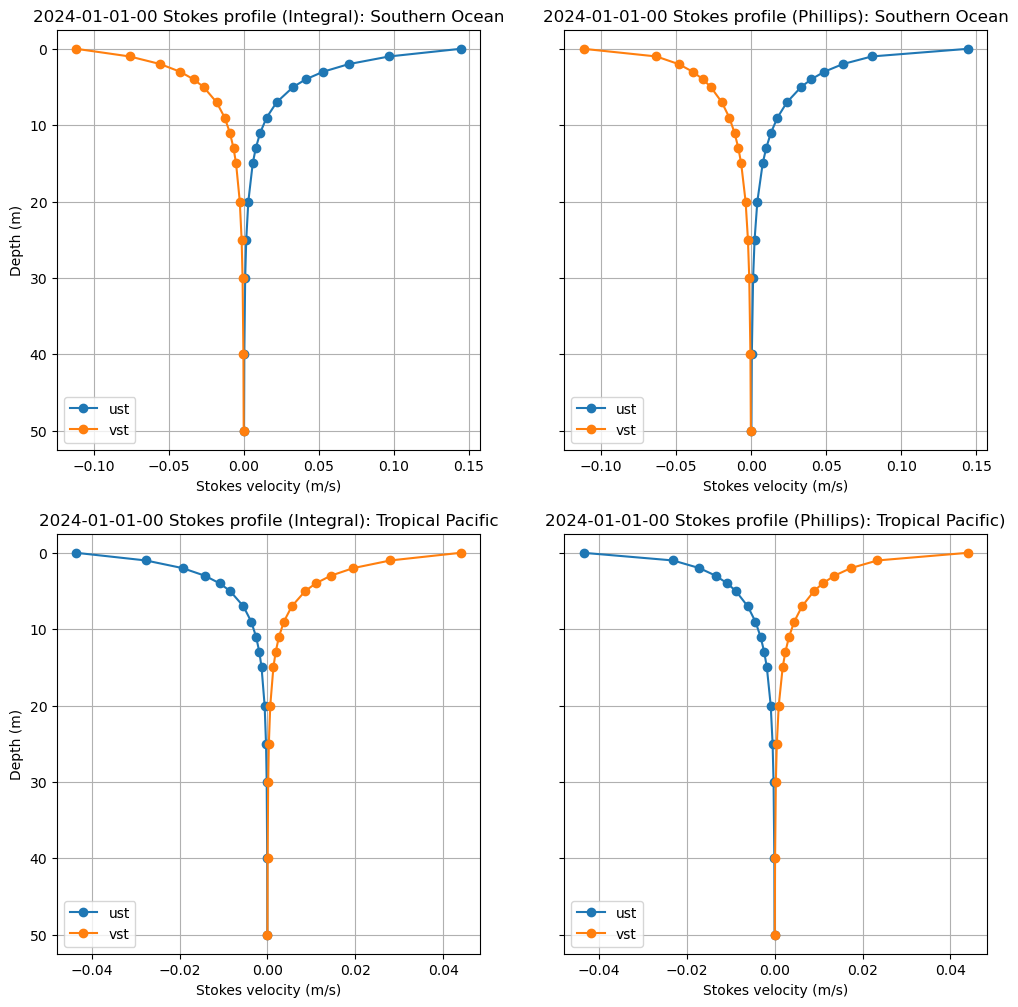

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 12), sharey=True)

# Integral profile
axes[0,0].plot(p_integral_so_reg["ust_z"].isel(time=500), p_integral_so_reg["depth"], label="ust", marker="o")
axes[0,0].plot(p_integral_so_reg["vst_z"].isel(time=500), p_integral_so_reg["depth"], label="vst", marker="o")
axes[0,0].invert_yaxis()
axes[0,0].set_xlabel("Stokes velocity (m/s)")
axes[0,0].set_ylabel("Depth (m)")
axes[0,0].set_title("2024-01-01-00 Stokes profile (Integral): Southern Ocean")
axes[0,0].legend()
axes[0,0].grid()

# Phillips profile
axes[0,1].plot(p_phillips_so_reg["ust_z"].isel(time=500), p_phillips_so_reg["depth"], label="ust", marker="o")
axes[0,1].plot(p_phillips_so_reg["vst_z"].isel(time=500), p_phillips_so_reg["depth"], label="vst", marker="o")
axes[0,1].set_xlabel("Stokes velocity (m/s)")
axes[0,1].set_title("2024-01-01-00 Stokes profile (Phillips): Southern Ocean")
axes[0,1].legend()
axes[0,1].grid()

# Integral profile
axes[1,0].plot(p_integral_tp_reg["ust_z"].isel(time=500), p_integral_tp_reg["depth"], label="ust", marker="o")
axes[1,0].plot(p_integral_tp_reg["vst_z"].isel(time=500), p_integral_tp_reg["depth"], label="vst", marker="o")
axes[1,0].set_xlabel("Stokes velocity (m/s)")
axes[1,0].set_ylabel("Depth (m)")
axes[1,0].set_title("2024-01-01-00 Stokes profile (Integral): Tropical Pacific")
axes[1,0].legend()
axes[1,0].grid()

# Phillips profile
axes[1,1].plot(p_phillips_tp_reg["ust_z"].isel(time=500), p_phillips_tp_reg["depth"], label="ust", marker="o")
axes[1,1].plot(p_phillips_tp_reg["vst_z"].isel(time=500), p_phillips_tp_reg["depth"], label="vst", marker="o")
axes[1,1].set_xlabel("Stokes velocity (m/s)")
axes[1,1].set_title("2024-01-01-00 Stokes profile (Phillips): Tropical Pacific)")
axes[1,1].legend()
axes[1,1].grid()

# plt.tight_layout()
plt.show()

## Separate surface Stokes drift velocity into (1) wind wave and (3) total swells component
**One can separate the surface Stokes drift velocity** $u_{so}$ to: $$u_{so}\hat{\theta}=u_{s,ww}\hat{\theta}_{ww}+u_{s,ts}\hat{\theta}_{ts}$$
- where:
    - $\hat{\theta}=(\sin{\theta}, \cos{\theta})$, $\hat{\theta}_{ww}=(\sin{\theta_{ww}}, \cos{\theta_{ww}})$ and $\hat{\theta}_{ts}=(\sin{\theta_{ts}}, \cos{\theta_{ts}})$: direction vectors for original surface Stokes drift velocity, wind waves and total swell components, respectively.
    - $u_{so}$, $u_{s,ww}$ and $u_{s,ts}$: velocity magnitude (scalar) for original surface Stokes drift velocity, wind waves and total swell components, respectively.

Given that: $$\hat{\theta}_{ts} \times \hat{\theta}_{ts} = 0$$
- one can get: $$\begin{align} u_{so}(\hat{\theta} \times \hat{\theta}_{ts})&=u_{s,ww}(\hat{\theta}_{ww}\times \hat{\theta}_{ts})\\ u_{so}(\hat{\theta} \times \hat{\theta}_{ww})&=u_{s,ts}(\hat{\theta}_{ts}\times \hat{\theta}_{ww})\end{align}$$
- cross products of unit velocity direction vector: $$\begin{align} \hat{\theta} \times \hat{\theta}_{ts} &= \sin{(\theta - \theta_{ts})} \\ \hat{\theta}_{ww} \times \hat{\theta}_{ts} &= \sin{(\theta_{ww} - \theta_{ts})} \\ \hat{\theta}_{ts} \times \hat{\theta}_{ww} &= \sin{(\theta_{ts} - \theta_{ww})}\end{align}$$
- Thus: $$\begin{align} u_{s,ww}&=u_{so}\frac{\sin{(\theta - \theta_{ts})}}{\sin{(\theta_{ww} - \theta_{ts})}} \\u_{s,ts}&=u_{so}\frac{\sin{(\theta - \theta_{ww})}}{\sin{(\theta_{ts} - \theta_{ww})}}  \end{align}$$

**The above expressions become ill-conditioned when the wind sea and swell directions are nearly aligned or opposite** $\sin(\theta_{ts} - \theta_{ww})\approx 0$. In this case, small numerical errors can lead ot large uncertainties or even negative values of the estimated magnitudes. To mitigate this, the practical procedure is:
- Compute both $u_{s,ww}, u_{s,ts}$ using the two projection formulas above
- Retain the component that yields a **nonnegative magnitude**, and compute the other component from the vector relation $u_{so}\hat{\theta}=u_{s,ww}\hat{\theta}_{ww}+u_{s,ts}\hat{\theta}_{ts}$.
This ensures a physically consistent decomposition where component magnitudes remain nonnegative.


### Check if decomposition yields infinitive magnitude

In [4]:
chunks = {"time": 48, "latitude": 88, "longitude": 176}
# surface Stokes
ust0 = stokes_globe["ust"].sel(time=slice("2024-01-01", "2024-02-01")).chunk(chunks)
vst0 = stokes_globe["vst"].sel(time=slice("2024-01-01", "2024-02-01")).chunk(chunks)
# mean wave direction
mdww = wave_globe["mdww"].sel(time=slice("2024-01-01", "2024-02-01")).chunk(chunks)
mdts = wave_globe["mdts"].sel(time=slice("2024-01-01", "2024-02-01")).chunk(chunks)

# direction vector
theta = np.arctan2(ust0, vst0)  # --> u = U*sin(\theta), v = U*cos(\theta), degress rotate from north and going clockwise
theta_ww = np.deg2rad((mdww + 180) % 360)
theta_ts = np.deg2rad((mdts + 180) % 360)

In [5]:
# check when sin(theta_ww-theta_ts)~0, if  sin(theta-theta_ts) is also ~0
mask = np.abs(np.sin(theta_ww - theta_ts)) < 1e-3
test = np.abs(np.sin(theta - theta_ts))
print(test.where(mask).quantile([0.25, 0.5, 0.75, 0.95]).compute())

/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 12.74 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


<xarray.DataArray (quantile: 4)> Size: 32B
array([0.02399962, 0.05772301, 0.13643429, 0.6216466 ])
Coordinates:
  * quantile  (quantile) float64 32B 0.25 0.5 0.75 0.95


- the above quantile shows the $|\sin{\theta - \theta_{ts}}|$ conditioned on $|\sin{\theta_{ww} - \theta_{ts}}|\lt 10^{-3}$ (i.e., wind wave direction aligns or opposite to the swell direction).
- interpretation:
    - mean (0.058): mean $\Delta \theta = \Delta (\theta - \theta_{ts})\approx 3.3$
    - 95th percentile (0.62): large misalignment
    - when wind seea and swell are nearly collinear, the surface Stokes can deviate substantially

### Two-regime strategy
- when distinct direction between wind wave and total swells: apply the decomposition
- when near collinear (near parallel and/or opposite): consider mean wave parameters (no decomposition of waves)

In [23]:
dtheta = np.abs(theta_ww - theta_ts)
# wrap to range [0,pi]
dtheta = xr.where(dtheta > np.pi, 2 * np.pi - dtheta, dtheta)

# threshold to identify aligned cases
THRESHOLD = np.pi / 18 # 10 degrees in radians
mask_collinear = dtheta < THRESHOLD

/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 10.35 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


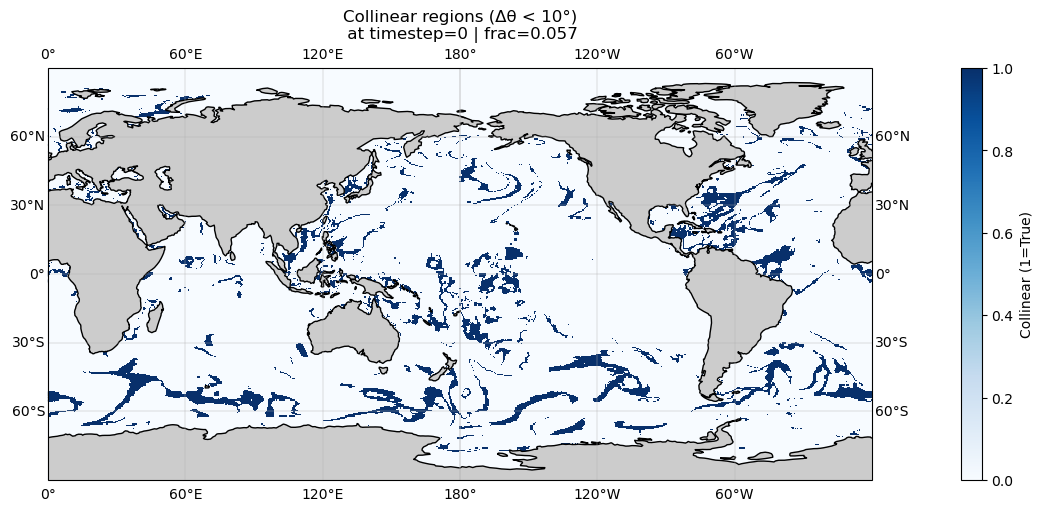

In [26]:
t_test = 0
mask_collinear_t = mask_collinear.isel(time=t_test).compute()
frac = mask_collinear_t.mean().item()

fig, ax = plt.subplots(
    1, 1, figsize=(12, 5),
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=180)},
    constrained_layout=True
)
pcm = ax.pcolormesh(
    mask_collinear_t.longitude,
    mask_collinear_t.latitude,
    mask_collinear_t,
    shading='auto',
    cmap='Blues',
    transform=ccrs.PlateCarree()
)

ax.coastlines()
ax.add_feature(cfeature.LAND, facecolor="0.8", zorder=1)
ax.gridlines(draw_labels=True, linewidth=0.3)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Collinear regions (Δθ < 10°)\n at timestep={t_test} | frac={frac:.3f}")

plt.colorbar(pcm, ax=ax, label="Collinear (1=True)")
plt.show()

/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 10.35 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


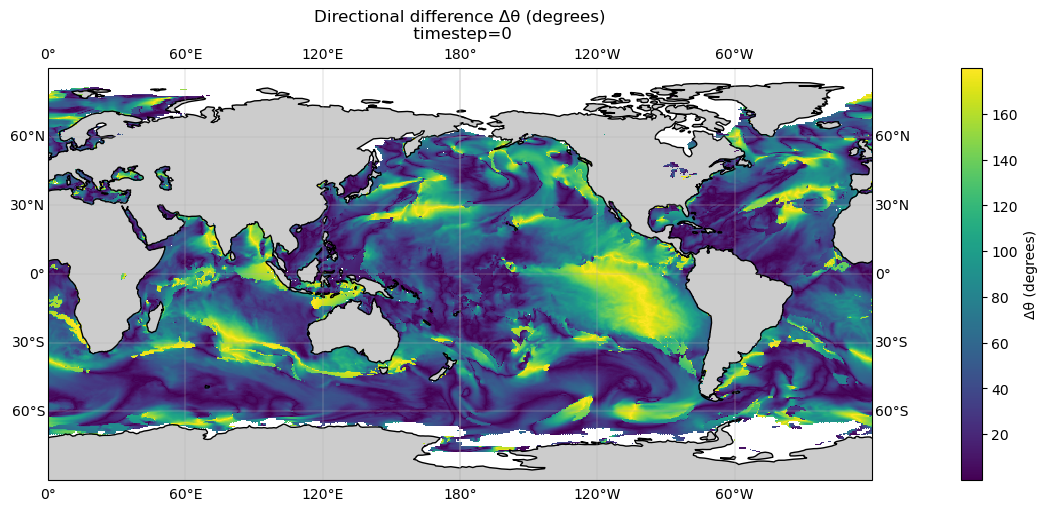

In [29]:
dtheta_deg = np.rad2deg(dtheta)
dtheta_t = dtheta_deg.isel(time=t_test).compute()

fig, ax = plt.subplots(
    1, 1, figsize=(12, 5),
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=180)},
    constrained_layout=True
)

pcm = ax.pcolormesh(
    dtheta_t.longitude,
    dtheta_t.latitude,
    dtheta_t,
    shading='auto',
    cmap='viridis',
    transform=ccrs.PlateCarree()
)

ax.coastlines()
ax.add_feature(cfeature.LAND, facecolor="0.8", zorder=0)
ax.gridlines(draw_labels=True, linewidth=0.3)

ax.set_title(f"Directional difference Δθ (degrees)\n timestep={t_test}")
plt.colorbar(pcm, ax=ax, label="Δθ (degrees)")
plt.show()

### Stokes transports in 2 components

In [ ]:
# chunk
chunks = {"time": 96, "latitude": 88, "longitude": 176}

# paras for wind waves
shww = wave_globe["shww"].chunk(chunks)
p1ww = wave_globe["p1ww"].chunk(chunks)
mdww = wave_globe["mdww"].chunk(chunks)

# paras for total swells
shts = wave_globe["shts"].chunk(chunks)
p1ps = wave_globe["p1ps"].chunk(chunks)
mdts = wave_globe["mdts"].chunk(chunks)

In [8]:
# Wind wave (ww)
Vst_u_ww, Vst_v_ww = estimate_stokes_transport(shww, p1ww, mdww)
ds_Vst_ww = xr.Dataset({
    "Vst_u_ww":  Vst_u_ww,
    "Vst_v_ww":  Vst_v_ww
})
ds_Vst_ww.to_netcdf("/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/era5_Stokes_transport_estimated_windwave_2024.nc")

/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 10.76 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [10]:
# Total Swells (ts)
Vst_u_ts, Vst_v_ts = estimate_stokes_transport(shts, p1ps, mdts)
ds_Vst_ts = xr.Dataset({
    "Vst_u_ts":  Vst_u_ts,
    "Vst_v_ts":  Vst_v_ts
})
ds_Vst_ts.to_netcdf("/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/era5_Stokes_transport_estimated_totalswell_2024.nc")

/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 10.55 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 10.34 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


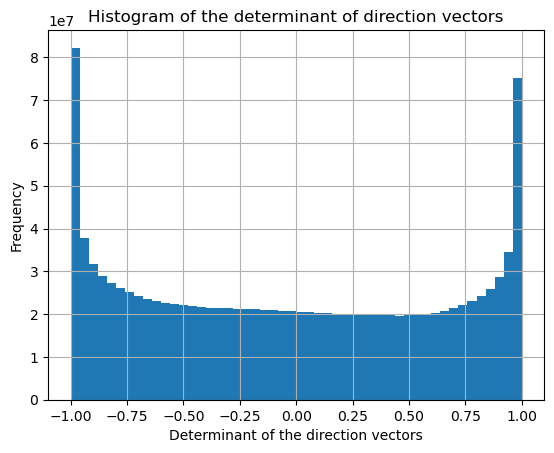

In [6]:
# Surface Stokes direction 
ust = stokes_globe["ust"].values # eastward
vst = stokes_globe["vst"].values # northward

# normalise to get direction
ust_unit = ust / np.sqrt(ust**2 + vst**2)
vst_unit = vst / np.sqrt(ust**2 + vst**2)

# wave direction (GOING TO)
theta_ww = np.deg2rad((wave_globe["mdww"] + 180) % 360)
theta_ts = np.deg2rad((wave_globe["mdts"] + 180) % 360)

# convert to unit vector
uww_unit = np.sin(theta_ww)
vww_unit = np.cos(theta_ww)
uts_unit = np.sin(theta_ts)
vts_unit = np.cos(theta_ts)

# sin(angle difference) via cross product
sin_diff_ww = uww_unit * vts_unit - vww_unit * uts_unit

plt.hist(sin_diff_ww.values.flatten(), bins=50)
plt.xlabel("Determinant of the direction vectors")
plt.ylabel("Frequency")
plt.title("Histogram of the determinant of direction vectors")
plt.grid()

### Exponential Integral Profile (Breivik et al. 2014)

### Phillips Spectrum Profile (Breivik et al. 2016)